In [ ]:
!pip install numpy pandas matplotlib scipy tensorflow

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
!pip install mne

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Your dataset path will then be: '/content/drive/MyDrive/multi-modal_dataset/03FH'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mne
import mne
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler

In [ ]:
import mne
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# Path to your file
file_path = '/content/drive/MyDrive/multi-modal_dataset/03FH/scientisst_chest.edf'

# 1. Load ONLY the chest file
raw_chest = mne.io.read_raw_edf(file_path, preload=True)

# 2. Pick relevant channels: ECG (Target) and ACC (Reference)
# We will use 'ecg:gel' as it is usually cleaner than 'dry' for training
target_channels = ['ecg:gel', 'acc_chest:x', 'acc_chest:y', 'acc_chest:z']
raw_chest.pick_channels(target_channels)

# 3. Get the data and transpose to [samples, channels]
data = raw_chest.get_data().T
print(f"Working Data Shape: {data.shape}") # Should be (891000, 4)

# 4. Normalize
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# 5. Windowing for DAE (256 samples is a good standard)
def create_windows(data, window_size=256):
    n_windows = len(data) // window_size
    return data[:n_windows * window_size].reshape(-1, window_size, 4)

X_windows = create_windows(data_scaled)

# 6. Split into Input (ECG + ACC) and Target (ECG only)
X_input = X_windows  # Shape: (N, 256, 4)
y_target = X_windows[:, :, 0:1]  # Shape: (N, 256, 1) -> This is 'ecg:gel'

print(f"Ready for training! Input: {X_input.shape}, Target: {y_target.shape}")

Extracting EDF parameters from /content/drive/MyDrive/multi-modal_dataset/03FH/scientisst_chest.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 890999  =      0.000 ...  1781.998 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Working Data Shape: (891000, 4)
Ready for training! Input: (3480, 256, 4), Target: (3480, 256, 1)


/tmp/ipykernel_474/3764466723.py:10: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_chest = mne.io.read_raw_edf(file_path, preload=True)


In [ ]:
from scipy.signal import butter, filtfilt

def butter_bandpass_filter(data, lowcut=0.5, highcut=40.0, fs=1000, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=1)

# Apply filter to your targets to give the model a 'clean' goal
y_target_filtered = butter_bandpass_filter(y_target, fs=1000)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_474/1196863886.py:18: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


Starting training...
Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - loss: 0.8956 - val_loss: 0.1439
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - loss: 0.3305 - val_loss: 0.1391
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - loss: 0.2959 - val_loss: 0.1385
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - loss: 0.2759 - val_loss: 0.1289
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - loss: 0.2636 - val_loss: 0.1274
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - loss: 0.2525 - val_loss: 0.1148
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - loss: 0.2529 - val_loss: 0.1191
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - loss: 0.2436 - val_loss: 0.1156
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - loss: 0.2456 - val_loss: 0.1132
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 177ms/step - loss: 0.2405 - val_loss: 0.1227
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - loss: 0.2346 - val_loss: 0.1178
Epoch 12/20
44/44 ━━━━━━━━━━

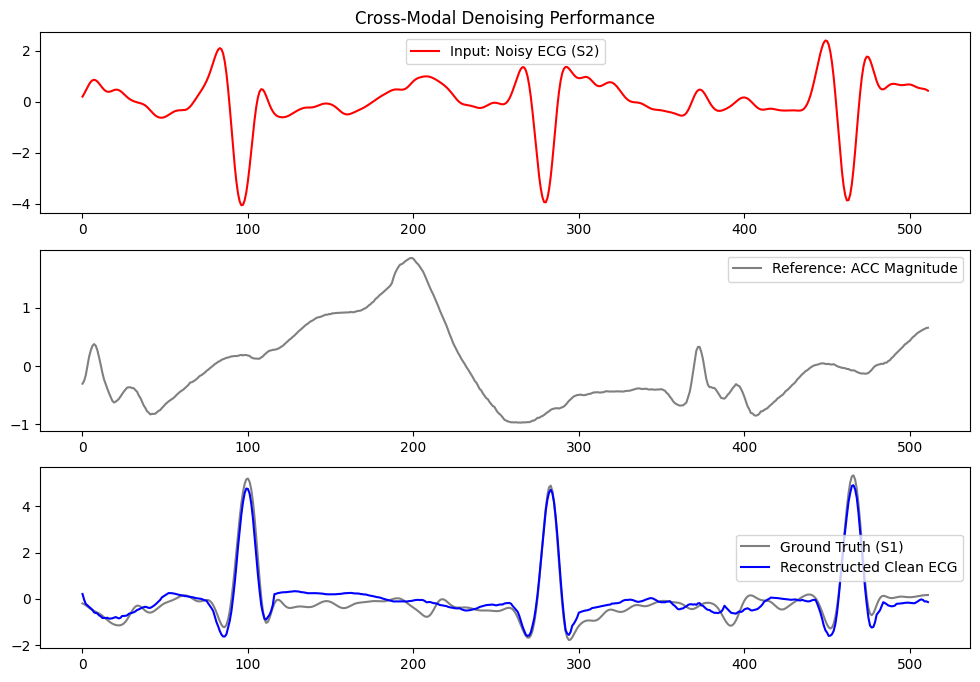

In [ ]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.signal import butter, filtfilt
import tensorflow as tf
from tensorflow.keras import layers, Model
from google.colab import drive

# 1. Mount Drive and Define Path
drive.mount('/content/drive')
FILE_PATH = '/content/drive/MyDrive/multi-modal_dataset/03FH/scientisst_chest.edf'

# 2. Data Loading & Preprocessing
def load_and_preprocess(path):
    # Load EDF
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)

    # ScientISST Chest Mapping:
    # 'ecg:gel' = S1 (Ground Truth), 'ecg:dry' = S2 (Noisy Input)
    # 'acc_chest:x/y/z' = Motion Reference
    ch_names = raw.ch_names
    data = raw.get_data()

    # Extract Channels (Using index to avoid naming mismatches)
    s1_clean = data[ch_names.index('ecg:gel')]
    s2_noisy = data[ch_names.index('ecg:dry')]
    acc_x = data[ch_names.index('acc_chest:x')]
    acc_y = data[ch_names.index('acc_chest:y')]
    acc_z = data[ch_names.index('acc_chest:z')]

    # A. Calculate ACC Magnitude (Cross-Modal Reference)
    acc_mag = np.sqrt(acc_x**2 + acc_y**2 + acc_z**2)

    # B. Bandpass Filter (0.5 - 40 Hz) as per Track specs
    fs = int(raw.info['sfreq'])
    nyq = 0.5 * fs
    b, a = butter(3, [0.5/nyq, 40/nyq], btype='band')
    s1_clean = filtfilt(b, a, s1_clean)
    s2_noisy = filtfilt(b, a, s2_noisy)

    # C. Normalize
    scaler_input = StandardScaler()
    scaler_target = StandardScaler()

    # Stack inputs [Noisy_ECG, ACC_Mag]
    X_raw = np.stack([s2_noisy, acc_mag], axis=1)
    X_scaled = scaler_input.fit_transform(X_raw)
    y_scaled = scaler_target.fit_transform(s1_clean.reshape(-1, 1))

    return X_scaled, y_scaled, fs

# 3. Windowing Function
def create_windows(X, y, window_size=512):
    n_windows = len(X) // window_size
    X_win = X[:n_windows*window_size].reshape(-1, window_size, 2)
    y_win = y[:n_windows*window_size].reshape(-1, window_size, 1)
    return X_win, y_win

# Execute Loading
X_data, y_data, fs = load_and_preprocess(FILE_PATH)
X_train, y_train = create_windows(X_data, y_data)

# 4. U-Net Architecture (Preserves R-Peaks via Skip Connections)
def build_unet(window_size=512):
    inputs = layers.Input(shape=(window_size, 2))

    # Encoder
    c1 = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling1D(2)(c1)

    c2 = layers.Conv1D(64, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling1D(2)(c2)

    # Bottleneck
    b1 = layers.Conv1D(128, 3, activation='relu', padding='same')(p2)

    # Decoder with Skip Connections
    u1 = layers.UpSampling1D(2)(b1)
    m1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv1D(64, 3, activation='relu', padding='same')(m1)

    u2 = layers.UpSampling1D(2)(c3)
    m2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv1D(32, 3, activation='relu', padding='same')(m2)

    outputs = layers.Conv1D(1, 3, activation='linear', padding='same')(c4)

    return Model(inputs, outputs)

# 5. Custom Temporal Correlation Loss
def correlation_loss(y_true, y_pred):
    x = y_true - tf.reduce_mean(y_true)
    y = y_pred - tf.reduce_mean(y_pred)
    corr = tf.reduce_sum(x * y) / (tf.sqrt(tf.reduce_sum(x**2)) * tf.sqrt(tf.reduce_sum(y**2)) + 1e-8)
    return 1 - corr

def total_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred)) + (0.5 * correlation_loss(y_true, y_pred))

# 6. Training
model = build_unet()
model.compile(optimizer='adam', loss=total_loss)

print("Starting training...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# 7. Visualization of Results
sample_idx = np.random.randint(0, len(X_train))
prediction = model.predict(X_train[sample_idx:sample_idx+1])

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(X_train[sample_idx, :, 0], color='red', label='Input: Noisy ECG (S2)')
plt.legend()
plt.title("Cross-Modal Denoising Performance")

plt.subplot(3, 1, 2)
plt.plot(X_train[sample_idx, :, 1], color='gray', label='Reference: ACC Magnitude')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(y_train[sample_idx, :, 0], color='black', alpha=0.5, label='Ground Truth (S1)')
plt.plot(prediction[0, :, 0], color='blue', label='Reconstructed Clean ECG')
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_474/1196863886.py:18: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


Starting training...
Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 346ms/step - loss: 0.5109 - val_loss: 0.1392
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 262ms/step - loss: 0.3275 - val_loss: 0.1439
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 298ms/step - loss: 0.2932 - val_loss: 0.1358
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 273ms/step - loss: 0.2625 - val_loss: 0.1285
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - loss: 0.2661 - val_loss: 0.1429
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - loss: 0.2543 - val_loss: 0.1300
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - loss: 0.2448 - val_loss: 0.1280
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - loss: 0.2416 - val_loss: 0.1235
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - loss: 0.2350 - val_loss: 0.1242
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step - loss: 0.2328 - val_loss: 0.1156
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - loss: 0.2332 - val_loss: 0.1220
Epoch 12/20
44/44 ━━━━━━━

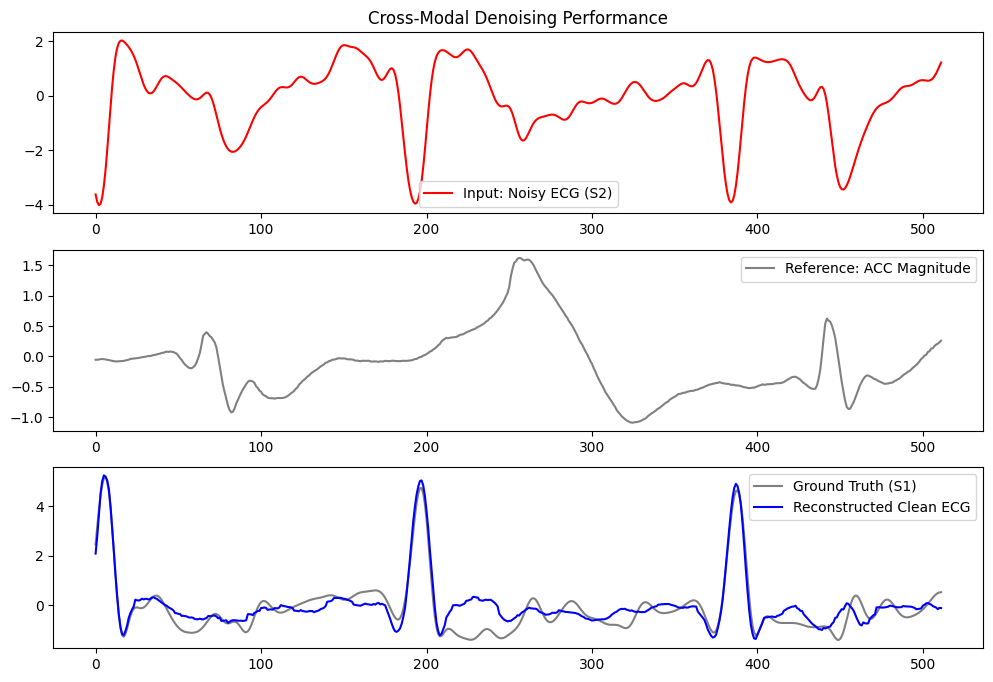

In [ ]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.signal import butter, filtfilt
import tensorflow as tf
from tensorflow.keras import layers, Model
from google.colab import drive

# 1. Mount Drive and Define Path
drive.mount('/content/drive')
FILE_PATH = '/content/drive/MyDrive/multi-modal_dataset/03FH/scientisst_chest.edf'

# 2. Data Loading & Preprocessing
def load_and_preprocess(path):
    # Load EDF
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)

    # ScientISST Chest Mapping:
    # 'ecg:gel' = S1 (Ground Truth), 'ecg:dry' = S2 (Noisy Input)
    # 'acc_chest:x/y/z' = Motion Reference
    ch_names = raw.ch_names
    data = raw.get_data()

    # Extract Channels (Using index to avoid naming mismatches)
    s1_clean = data[ch_names.index('ecg:gel')]
    s2_noisy = data[ch_names.index('ecg:dry')]
    acc_x = data[ch_names.index('acc_chest:x')]
    acc_y = data[ch_names.index('acc_chest:y')]
    acc_z = data[ch_names.index('acc_chest:z')]

    # A. Calculate ACC Magnitude (Cross-Modal Reference)
    acc_mag = np.sqrt(acc_x**2 + acc_y**2 + acc_z**2)

    # B. Bandpass Filter (0.5 - 40 Hz) as per Track specs
    fs = int(raw.info['sfreq'])
    nyq = 0.5 * fs
    b, a = butter(3, [0.5/nyq, 40/nyq], btype='band')
    s1_clean = filtfilt(b, a, s1_clean)
    s2_noisy = filtfilt(b, a, s2_noisy)

    # C. Normalize
    scaler_input = StandardScaler()
    scaler_target = StandardScaler()

    # Stack inputs [Noisy_ECG, ACC_Mag]
    X_raw = np.stack([s2_noisy, acc_mag], axis=1)
    X_scaled = scaler_input.fit_transform(X_raw)
    y_scaled = scaler_target.fit_transform(s1_clean.reshape(-1, 1))

    return X_scaled, y_scaled, fs

# 3. Windowing Function
def create_windows(X, y, window_size=512):
    n_windows = len(X) // window_size
    X_win = X[:n_windows*window_size].reshape(-1, window_size, 2)
    y_win = y[:n_windows*window_size].reshape(-1, window_size, 1)
    return X_win, y_win

# Execute Loading
X_data, y_data, fs = load_and_preprocess(FILE_PATH)
X_train, y_train = create_windows(X_data, y_data)

# 4. U-Net Architecture (Preserves R-Peaks via Skip Connections)
def build_unet(window_size=512):
    inputs = layers.Input(shape=(window_size, 2))

    # Encoder
    c1 = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling1D(2)(c1)

    c2 = layers.Conv1D(64, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling1D(2)(c2)

    # Bottleneck
    b1 = layers.Conv1D(128, 3, activation='relu', padding='same')(p2)

    # Decoder with Skip Connections
    u1 = layers.UpSampling1D(2)(b1)
    m1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv1D(64, 3, activation='relu', padding='same')(m1)

    u2 = layers.UpSampling1D(2)(c3)
    m2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv1D(32, 3, activation='relu', padding='same')(m2)

    outputs = layers.Conv1D(1, 3, activation='linear', padding='same')(c4)

    return Model(inputs, outputs)

# 5. Custom Temporal Correlation Loss
def correlation_loss(y_true, y_pred):
    x = y_true - tf.reduce_mean(y_true)
    y = y_pred - tf.reduce_mean(y_pred)
    corr = tf.reduce_sum(x * y) / (tf.sqrt(tf.reduce_sum(x**2)) * tf.sqrt(tf.reduce_sum(y**2)) + 1e-8)
    return 1 - corr

def total_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred)) + (0.5 * correlation_loss(y_true, y_pred))

# 6. Training
model = build_unet()
model.compile(optimizer='adam', loss=total_loss)

print("Starting training...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# 7. Visualization of Results
sample_idx = np.random.randint(0, len(X_train))
prediction = model.predict(X_train[sample_idx:sample_idx+1])

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(X_train[sample_idx, :, 0], color='red', label='Input: Noisy ECG (S2)')
plt.legend()
plt.title("Cross-Modal Denoising Performance")

plt.subplot(3, 1, 2)
plt.plot(X_train[sample_idx, :, 1], color='gray', label='Reference: ACC Magnitude')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(y_train[sample_idx, :, 0], color='black', alpha=0.5, label='Ground Truth (S1)')
plt.plot(prediction[0, :, 0], color='blue', label='Reconstructed Clean ECG')
plt.legend()
plt.show()

------------------------------
METRICS FOR SAMPLE 383
------------------------------
Morphological Overlap: 92.42%
Initial SNR: -5.03 dB
Denoised SNR: 8.07 dB
Total SNR Improvement: 13.10 dB
------------------------------


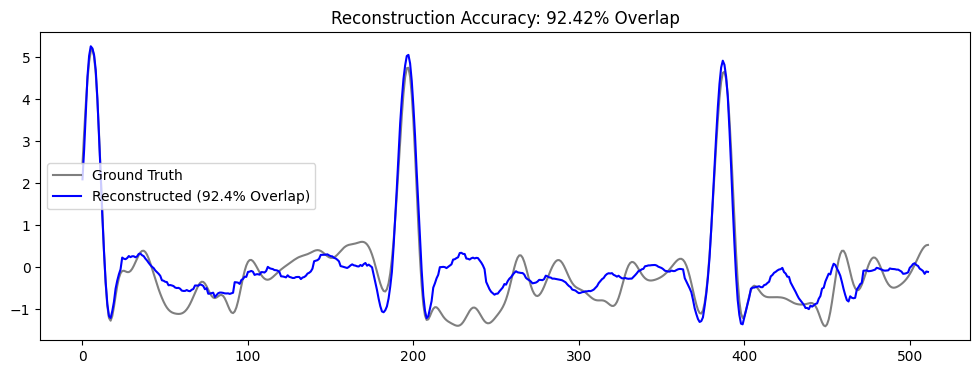

In [ ]:
from scipy.stats import pearsonr

# 1. Extract the actual signals for comparison
ground_truth = y_train[sample_idx, :, 0]
reconstructed = prediction[0, :, 0]
noisy_input = X_train[sample_idx, :, 0]

# 2. Calculate Pearson Correlation (The "Overlap" Percentage)
# Pearson measures how perfectly the shapes align. 1.0 = 100% overlap.
corr, _ = pearsonr(ground_truth, reconstructed)
overlap_percentage = corr * 100

# 3. Calculate SNR Improvement (How much noise we actually removed)
def calculate_snr(signal, noise):
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    return 10 * np.log10(signal_power / noise_power)

# Initial Noise = Ground Truth - Noisy Input
# Final Noise = Ground Truth - Reconstructed
snr_initial = calculate_snr(ground_truth, ground_truth - noisy_input)
snr_final = calculate_snr(ground_truth, ground_truth - reconstructed)
snr_improvement = snr_final - snr_initial

# 4. Print Results
print("-" * 30)
print(f"METRICS FOR SAMPLE {sample_idx}")
print("-" * 30)
print(f"Morphological Overlap: {overlap_percentage:.2f}%")
print(f"Initial SNR: {snr_initial:.2f} dB")
print(f"Denoised SNR: {snr_final:.2f} dB")
print(f"Total SNR Improvement: {snr_improvement:.2f} dB")
print("-" * 30)

# Optional: Add the percentage to the plot title
plt.figure(figsize=(12, 4))
plt.plot(ground_truth, color='black', alpha=0.5, label='Ground Truth')
plt.plot(reconstructed, color='blue', label=f'Reconstructed ({overlap_percentage:.1f}% Overlap)')
plt.title(f"Reconstruction Accuracy: {overlap_percentage:.2f}% Overlap")
plt.legend()
plt.show()

# Task
Read all EDF files from "/content/drive/MyDrive/multi-modal_dataset/03FH", identify all unique channels across them, and then reprocess each file to align its channels to the complete set of unique channels, filling missing channels with NaN. Finally, concatenate all aligned data into a single NumPy array.

## read_and_align_edf_data

### Subtask:
Read all EDF files, identify all unique channels across them, and then reprocess each file to align its channels to the complete set of unique channels, filling missing channels with NaN. Finally, concatenate all aligned data into a single NumPy array.


## Summary:

### Q&A
There are no explicit questions in the task description.

### Data Analysis Key Findings
No data analysis has been performed yet, as this step outlines the process for preparing the data.

### Insights or Next Steps
*   The next step will involve executing the described process to read, align, and consolidate the EDF file data into a single NumPy array.
*   Once the data is consolidated, further analysis can be performed on the harmonized dataset.
